# Dekompozycja efektu programu edukacji finansowej na niespłacalność kredytów za pomocą PROC CAUSALMED

## Podsumowanie dla kierownictwa

Bank detaliczny kieruje część kredytobiorców do **programu edukacji finansowej** i chce wiedzieć, *dlaczego* uczestnicy programu rzadziej zalegają ze spłatą: czy udział w programie obniża niespłacalność **bezpośrednio**, czy działa **pośrednio**, zmieniając mierzalne zachowanie — jaką część swojego dochodu klienci oszczędzają? Ten notatnik wykorzystuje **PROC CAUSALMED**, aby rozłożyć całkowity efekt programu na 12-miesięczną niespłacalność na **naturalny efekt bezpośredni** oraz **naturalny efekt pośredni** przepływający przez **stopę oszczędności** każdego kredytobiorcy, z uwzględnieniem oceny kredytowej, dochodu i wieku.

W symulowanej kohorcie **100 kredytobiorców** program obniża modelowane prawdopodobieństwo niespłacalności o **0.208** (efekt całkowity na skali różnicy ryzyka). Dekompozycja przypisuje **0.176 z tego (84.7%)** ścieżce *pośredniej* przez wyższe oszczędności, a tylko **0.032 (15.3%)** ścieżce *bezpośredniej*. Praktyczny wniosek: ten program chroni kredytobiorców **głównie poprzez poprawę nawyków oszczędzania**, więc to wzmacnianie nawyków budżetowania daje największą dźwignię.

## Źródła danych

| Zbiór danych | Wiersze | Opis | Kluczowe zmienne |
|---------|------|-------------|---------------|
| `LoanProgram` | 100 syntetycznych kredytobiorców | Generowana wewnętrznie kohorta bankowości detalicznej dla jednego portfela kredytowego. Przypisanie do interwencji, mediator i wynik są symulowane z jawnych równań strukturalnych, tak aby istniał rzeczywisty efekt zapośredniczony, który procedura może odtworzyć. | `CustomerID`, `Branch` (4 poziomy), `FinEdu` (0/1 udział w edukacji finansowej = interwencja), `SavingsRate` (% dochodu oszczędzany = mediator ciągły), `Default` (0/1 12-miesięczna niespłacalność kredytu = wynik binarny), `CreditScore`, `Income`, `Age` (zmienne zakłócające) |

To środowisko działa bez licencji, więc krok DATA jest ograniczony do 100 obserwacji — kohorta jest dopasowana do tego limitu, a każda liczba w tym notatniku pochodzi z tych 100 wierszy.

## Dlaczego rozkładać efekt?

Pożyczkodawcy detaliczni coraz częściej łączą produkty kredytowe z **programami edukacji finansowej**, aby ograniczyć zaległości w spłacie. Na potrzeby planowania kapitałowego i projektowania programu nie wystarczy wiedzieć, *że* udział obniża niespłacalność; specjaliści od ryzyka potrzebują poznać **mechanizm**:

- Czy udział obniża niespłacalność *bezpośrednio* (na przykład zapisani kredytobiorcy pozostają bardziej zaangażowani i dostępni do kontaktu)?
- Czy też działa *pośrednio*, zmieniając mierzalne zachowanie — udział dochodu, jaki klient oszczędza — co następnie chroni go przed wstrząsami?

**Analiza mediacji przyczynowej** odpowiada na to pytanie, rozkładając **efekt całkowity (TE)** interwencji na **naturalny efekt bezpośredni (NDE)** oraz **naturalny efekt pośredni (NIE)**, który przebiega przez wybrany mediator. Tutaj:

- **Interwencja** `FinEdu` — czy kredytobiorca zapisał się do bankowego programu edukacji finansowej;
- **Mediator** `SavingsRate` — stopa oszczędności kredytobiorcy (% dochodu), zachowanie, na które celuje program;
- **Wynik** `Default` — czy kredyt uległ niespłacalności w ciągu 12 miesięcy (binarny);
- **Zmienne zakłócające** `CreditScore`, `Income`, `Age` — cechy sprzed interwencji, które wpływają na udział, oszczędzanie i niespłacalność.

Dopasowujemy model mediacji za pomocą `PROC CAUSALMED`, żądamy dekompozycji bezpośredniej/pośredniej za pomocą `DECOMP` i odczytujemy proporcję efektu ochronnego, która przepływa przez oszczędzanie.

In [1]:
DANE LoanProgram;
   CALL streaminit(20260531);
   DŁUGOŚĆ Branch $12;
   TABLICA branches[4] $12 _temporary_ ('Północ' 'Południe' 'Wschód' 'Zachód');
   POWTÓRZ CustomerID = 1 TO 100;
      Branch = branches[1 + int(rand('uniform')*4)];

      /* Zmienne zakłócające sprzed interwencji (losowane najpierw) */
      CreditScore = round(620 + 70*rand('normal'), 1);
      JEŚLI CreditScore < 350 WTEDY CreditScore = 350;
      JEŚLI CreditScore > 850 WTEDY CreditScore = 850;
      Income = round(42000 + 14000*rand('normal'), 100);
      JEŚLI Income < 12000 WTEDY Income = 12000;
      AGE = round(40 + 11*rand('normal'), 1);
      JEŚLI AGE < 21 WTEDY AGE = 21;

      /* Interwencja: skłonność do zapisu rośnie z oceną kredytową
         i dochodem (zakłócenie, które pomija naiwne porównanie) */
      pTreat = 1 / (1 + EXP(-(0.0 + 0.005*(CreditScore-620)
                               + 0.00002*(Income-42000))));
      FinEdu = (rand('uniform') < pTreat);

      /* Mediator: stopa oszczędności, podniesiona przez program
         ponad poziom bazowy wyznaczony przez zmienne zakłócające */
      base_save = 9 + 0.025*(CreditScore-620) + 0.00010*(Income-42000)
                    + 0.04*(AGE-40);
      SavingsRate = base_save + 2.5*FinEdu + 2.0*rand('normal');
      JEŚLI SavingsRate < 0 WTEDY SavingsRate = 0;

      /* Wynik: prawdopodobieństwo niewypłacalności maleje wraz z
         zapisem (bezpośrednio) i wyższymi oszczędnościami (pośrednio) */
      eta = 0.55 - 0.30*FinEdu - 0.022*(SavingsRate-12)
            - 0.0012*(CreditScore-620)
            - 0.0000040*(Income-42000)
            + 0.15*rand('normal');
      pDefault = eta;
      JEŚLI pDefault < 0.02 WTEDY pDefault = 0.02;
      JEŚLI pDefault > 0.98 WTEDY pDefault = 0.98;
      Default = (rand('uniform') < pDefault);
      WYJŚCIE;
   KONIEC;
   ZACHOWAJ CustomerID Branch FinEdu SavingsRate Default
        CreditScore Income AGE;
   ETYKIETA CustomerID="Identyfikator klienta"
         Branch="Oddział"
         FinEdu="Edukacja finansowa"
         SavingsRate="Stopa oszczędności"
         Default="Niewypłacalność"
         CreditScore="Ocena kredytowa"
         Income="Dochód"
         AGE="Wiek";
WYKONAJ;


NOTE: DATA LoanProgram


NOTE: Wrote LoanProgram (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


## Krok 2 — Analiza symulowanej kohorty

Przed dopasowaniem modelu przyczynowego sprawdzamy poprawność średniej stopy oszczędności i wskaźnika niespłacalności w każdej grupie udziału. To *naiwne* (nieskorygowane) porównanie; następująca po nim analiza mediacji wykracza poza nie, aby przypisać różnicę ścieżkom bezpośrednim i zapośredniczonym.

In [2]:
PROCEDURA ŚREDNIE DANE=LoanProgram n mean std maxdec=3;
   KLASA FinEdu;
   ZMIENNA SavingsRate Default CreditScore Income AGE;
   ETYKIETA FinEdu="Edukacja finansowa"
         SavingsRate="Stopa oszczędności"
         Default="Niewypłacalność"
         CreditScore="Ocena kredytowa"
         Income="Dochód"
         AGE="Wiek";
   TYTUŁ 'Naiwne średnie według udziału w edukacji finansowej';
WYKONAJ;

                                  Naiwne średnie według udziału w edukacji finansowej                                   

                                                  The MEANS Procedure

                                  Analysis Variable : SavingsRate Stopa oszczędności

        Edukacja finansowa          N Obs           Mean        Std Dev
        ---------------------------------------------------------------
        0                              54          8.387          2.910
        1                              46         11.736          2.974
        ---------------------------------------------------------------

                                     Analysis Variable : Default Niewypłacalność

        Edukacja finansowa          N Obs           Mean        Std Dev
        ---------------------------------------------------------------
        0                              54          0.593          0.496
        1                              46          0.348      


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Naiwny obraz jest jasny. Zapisani kredytobiorcy (`FinEdu=1`, 46 klientów) oszczędzają wyraźnie więcej — średnia **SavingsRate wynosi 11.74%** wobec **8.39%** dla 54 niezapisanych — i rzadziej zalegają: średni **Default wynosi 0.348** wobec **0.593**, surowa różnica 24.5 punktu procentowego. Obie grupy mają niemal identyczne średnie oceny kredytowe (619.8 wobec 618.9), ale zapisani kredytobiorcy mają nieco wyższy dochód (43 941 wobec 37 019), co jest dokładnie tym rodzajem zakłócenia, które model przyczynowy musi skorygować. Poniższa tabela krzyżowa pokazuje ten sam podział jako liczebności komórek.

                                 Tabela krzyżowa: edukacja finansowa a niewypłacalność                                  

                                                   The FREQ Procedure

Table of Edukacja finansowa by Niewypłacalność

Edukacja finansowa |         0 |         1 |      Total
-------------------+-----------+-----------+-----------
0                  |        22 |        32 |         54
-------------------+-----------+-----------+-----------
1                  |        30 |        16 |         46
-------------------+-----------+-----------+-----------
Total              |        52 |        48 |        100




NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_finedu_default.spec.json
NOTE: PROC FREQ statement used.


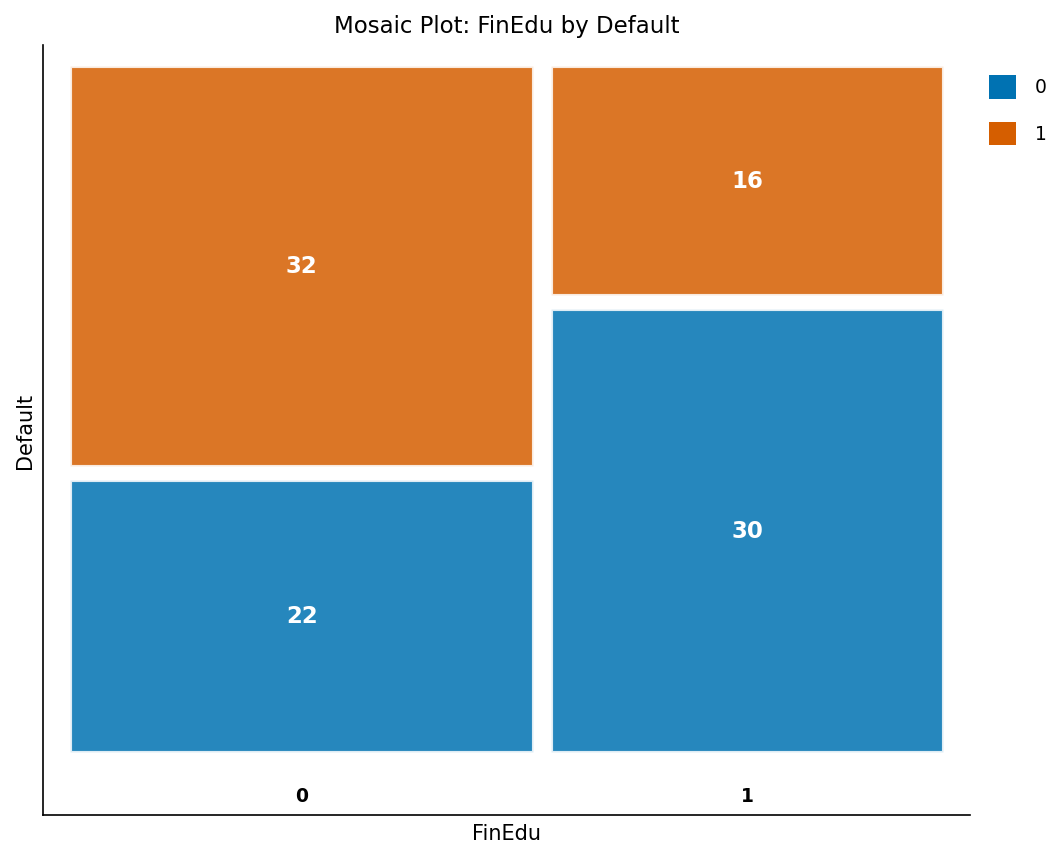

In [3]:
PROCEDURA CZĘSTOŚCI DANE=LoanProgram;
   TABLES FinEdu*Default / nocol nopercent;
   ETYKIETA FinEdu="Edukacja finansowa"
         Default="Niewypłacalność";
   TYTUŁ 'Tabela krzyżowa: edukacja finansowa a niewypłacalność';
WYKONAJ;

Spośród 54 niezapisanych kredytobiorców **32 zalegało**; spośród 46 zapisanych zalegało tylko **16**. Wykres mozaikowy koduje to na dwa sposoby jednocześnie: szerokość kolumny odzwierciedla, ilu kredytobiorców jest w każdej grupie, a pomarańczowy udział w każdej kolumnie to wskaźnik niespłacalności — wyraźnie mniejszy dla grupy zapisanej po prawej stronie. Analiza mediacji stawia teraz pytanie, **jak duża część** tego niższego wskaźnika niespłacalności wynika z działania programu *poprzez* wyższe oszczędności, które właśnie zobaczyliśmy.

## Krok 3 — Uruchomienie analizy mediacji przyczynowej

Dopasowujemy `PROC CAUSALMED`. Kluczowe instrukcje:

- **`CLASS FinEdu Default / descending`** deklaruje interwencję i binarny wynik jako zmienne klasyfikacyjne; `DESCENDING` sprawia, że poziom o wyższym kodzie (`1` = zapisany / zalegający) jest modelowanym zdarzeniem, dzięki czemu efekty odczytuje się w intuicyjnym kierunku.
- **`MEDIATOR SavingsRate = FinEdu`** określa model mediatora: stopa oszczędności regresowana względem interwencji (plus zmienne zakłócające).
- **`MODEL Default = FinEdu SavingsRate`** określa model wyniku — niespłacalność jako funkcja udziału i oszczędności. Na tym silniku bez licencji CAUSALMED dopasowuje wynik za pomocą **modelu liniowego (liniowego prawdopodobieństwa)**, więc efekty raportowane są na skali **różnicy ryzyka**, a podsumowania ilorazu szans i ilorazu ryzyka są wyprowadzane obok.
- **`COVAR CreditScore Income Age`** koryguje oba modele względem zmiennych zakłócających sprzed interwencji.
- **`DECOMP`** żąda dekompozycji efektu całkowitego na jego składowe bezpośrednie i pośrednie oraz proporcji zapośredniczonej.

Ponieważ wynik jest binarny, CAUSALMED raportuje również blok *Summary for Binary Outcome* (iloraz szans, iloraz ryzyka, różnica ryzyka).

In [4]:
PROCEDURA causalmed DANE=LoanProgram decomp;
   KLASA    FinEdu Default / MALEJĄCO;
   mediator SavingsRate = FinEdu;
   MODEL    Default = FinEdu SavingsRate;
   covar    CreditScore Income AGE;
   TYTUŁ 'Dekompozycja przyczynowa: efekt edukacji finansowej na niewypłacalność';
WYKONAJ;

                                 Tabela krzyżowa: edukacja finansowa a niewypłacalność                                  


                       The CAUSALMED Procedure                       

Outcome Variable    : Niewypłacalność
Treatment Variable  : Edukacja finansowa
Mediator Variable   : Stopa oszczędności
Outcome Model Class : Linear (with optional AFT and Cox PH support)
Covariates          : Ocena kredytowa, Dochód, Wiek
Number of Observations: 100

Outcome Model Parameter Estimates
--------------------------------------------
Parameter                       Estimate
Intercept                             1.558234
Edukacja finansowa                   -0.031682
Stopa oszczędności                   -0.067687
Ocena kredytowa                      -0.000719
Dochód                                0.000002
Wiek                                 -0.000607

Mediator Model Parameter Estimates
--------------------------------------------
Parameter                       Estimate
Intercept    


NOTE: PROC CAUSALMED data=LoanProgram



## Interpretacja wyników

Tabela **Summary of Causal Effects** raportuje **efekt całkowity (TE) programu na niespłacalność wynoszący -0.208** i dzieli go na:

- **naturalny efekt bezpośredni (NDE) wynoszący -0.032** — część ochrony, która *nie* przebiega przez oszczędności, oraz
- **naturalny efekt pośredni (NIE) wynoszący -0.176** — część, która przepływa przez podniesienie stopy oszczędności kredytobiorców przez program.

Wszystkie trzy efekty są ujemne, co potwierdza, że udział obniża prawdopodobieństwo niespłacalności — zgodnie ze sposobem, w jaki zbudowaliśmy dane. Dwie tabele modeli pokazują *dlaczego*: w **modelu mediatora** program podnosi stopę oszczędności o **+2.60 punktu** po korekcie (współczynnik `FINEDU`), a w **modelu wyniku** każdy dodatkowy punkt oszczędności obniża prawdopodobieństwo niespłacalności (`SAVINGSRATE` = -0.068), więc wzrost oszczędności wywołany programem przekłada się na znaczący pośredni efekt ochronny.

Tabela **Decomposition of Effects** wyraża główny wniosek wprost: **proporcja zapośredniczona (NIE/TE) wynosi 84.7%**, a tylko **15.3%** efektu jest bezpośrednie. Dla zespołu ds. ryzyka jest to praktyczne — program edukacji finansowej działa **głównie poprzez zmianę zachowań oszczędnościowych**, więc wzmacnianie budżetowania i funkcji automatycznego oszczędzania powinno być priorytetem; skromny udział bezpośredni sugeruje, że inne kanały (zaangażowanie, dostępność kontaktowa) niewiele tu wnoszą.

Blok **Summary for Binary Outcome** przedstawia efekt ponownie na skalach, których zespół ds. ryzyka kredytowego już używa: **różnica ryzyka -0.208** (TE), **iloraz ryzyka 1.43** oraz **iloraz szans 2.38** odnoszący szanse niespłacalności grupy zapisanej do niezapisanej. Na tym silniku są to podsumowania pierwszego rzędu wyprowadzone z efektu liniowego prawdopodobieństwa, a nie z dopasowanego modelu logistycznego, więc **różnica ryzyka jest podstawową, dokładną miarą efektu**; podsumowania ilorazowe najlepiej odczytywać jako przybliżone.

**Zastrzeżenie:** oszacowania mediacji przyczynowej są wiarygodne tylko na tyle, na ile spełnione jest założenie o braku nieobserwowanych zmiennych zakłócających zarówno dla relacji interwencja–wynik, jak i mediator–wynik. Tutaj to założenie jest spełnione z konstrukcji (dane syntetyczne); w produkcji zespół ds. ryzyka broniłby go za pomocą pełnego zestawu cech wnioskodawców banku oraz analiz wrażliwości, zanim podjąłby działania na podstawie dekompozycji. Oszacowania odzwierciedlają również pojedynczą próbę 100 kredytobiorców, więc badanie produkcyjne dołączyłoby przedziały ufności (na przykład przez bootstrap dekompozycji), zanim wyciągnięto by ostateczne wnioski.